In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

# Stats
from scipy import stats
from scipy.stats import skew

print(' All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('walkrun.csv')  

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'\nActivity counts:')
print(df['activity'].value_counts())
print(f'\nActivity mapping: 0 = Walking | 1 = Running')

Dataset shape : (88588, 11)
Columns       : ['date', 'time', 'username', 'wrist', 'activity', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']

Activity counts:
activity
1    44365
0    44223
Name: count, dtype: int64

Activity mapping: 0 = Walking | 1 = Running


In [3]:
print('=== DATASET INFO ===')
df.info()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [4]:
print('=== FIRST 5 ROWS ===')
df.head()

=== FIRST 5 ROWS ===


,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [5]:
print('=== STATISTICAL SUMMARY ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== STATISTICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
wrist,88588.000000,0.522170,0.499511,0.000000,0.000000,1.000000,1.000000,1.000000
activity,88588.000000,0.500801,0.500002,0.000000,0.000000,1.000000,1.000000,1.000000
acceleration_x,88588.000000,-0.074811,1.009299,-5.350500,-0.381800,-0.059500,0.355500,5.603300
acceleration_y,88588.000000,-0.562585,0.658458,-3.299000,-1.033500,-0.759100,-0.241775,2.668000
acceleration_z,88588.000000,-0.313956,0.486815,-3.753800,-0.376000,-0.221000,-0.085900,1.640300
gyro_x,88588.000000,0.004160,1.253423,-4.430600,-0.920700,0.018700,0.888800,4.874200
gyro_y,88588.000000,0.037203,1.198725,-7.464700,-0.644825,0.039300,0.733700,8.498000
gyro_z,88588.000000,0.022327,1.914423,-9.480000,-1.345125,0.006900,1.398200,11.266200


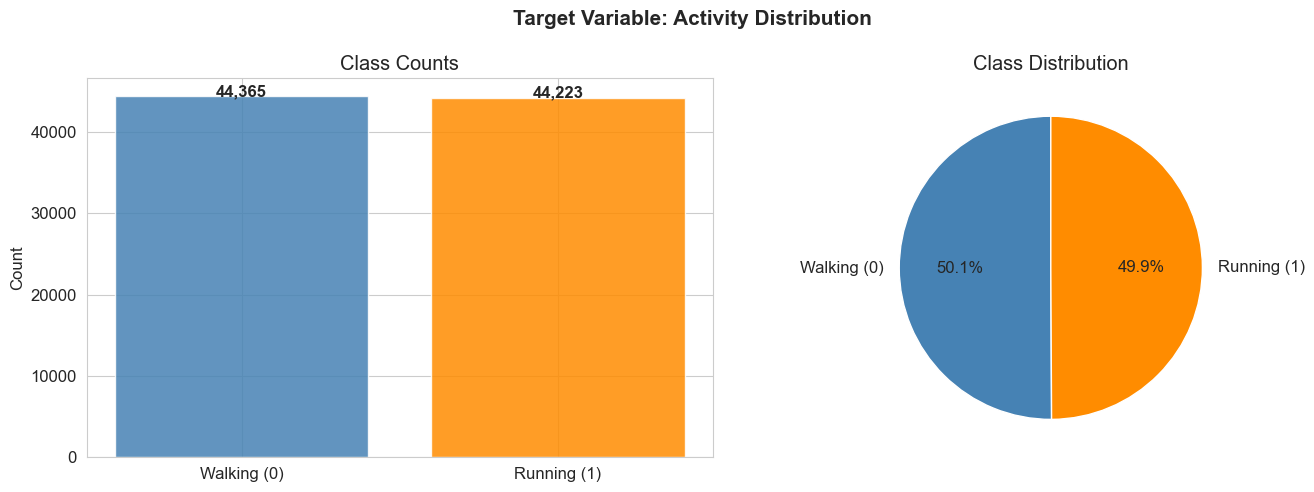

Balance ratio: 0.997
 Dataset is fairly balanced — no special resampling needed.


In [7]:
activity_counts = df['activity'].value_counts()
activity_labels = ['Walking (0)', 'Running (1)']
colors = ['steelblue', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable: Activity Distribution', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(activity_labels, activity_counts.values, color=colors, alpha=0.85)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Counts')
for bar, val in zip(bars, activity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(activity_counts.values, labels=activity_labels,
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

balance_ratio = activity_counts.min() / activity_counts.max()
print(f'Balance ratio: {balance_ratio:.3f}')
if balance_ratio > 0.8:
    print(' Dataset is fairly balanced — no special resampling needed.')
else:
    print(' Class imbalance detected — consider SMOTE or class_weight adjustments.')

In [8]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]

if miss_df.empty:
    print(' No missing values found in the dataset!')
else:
    print('  Missing values detected:')
    print(miss_df.to_string())

 No missing values found in the dataset!


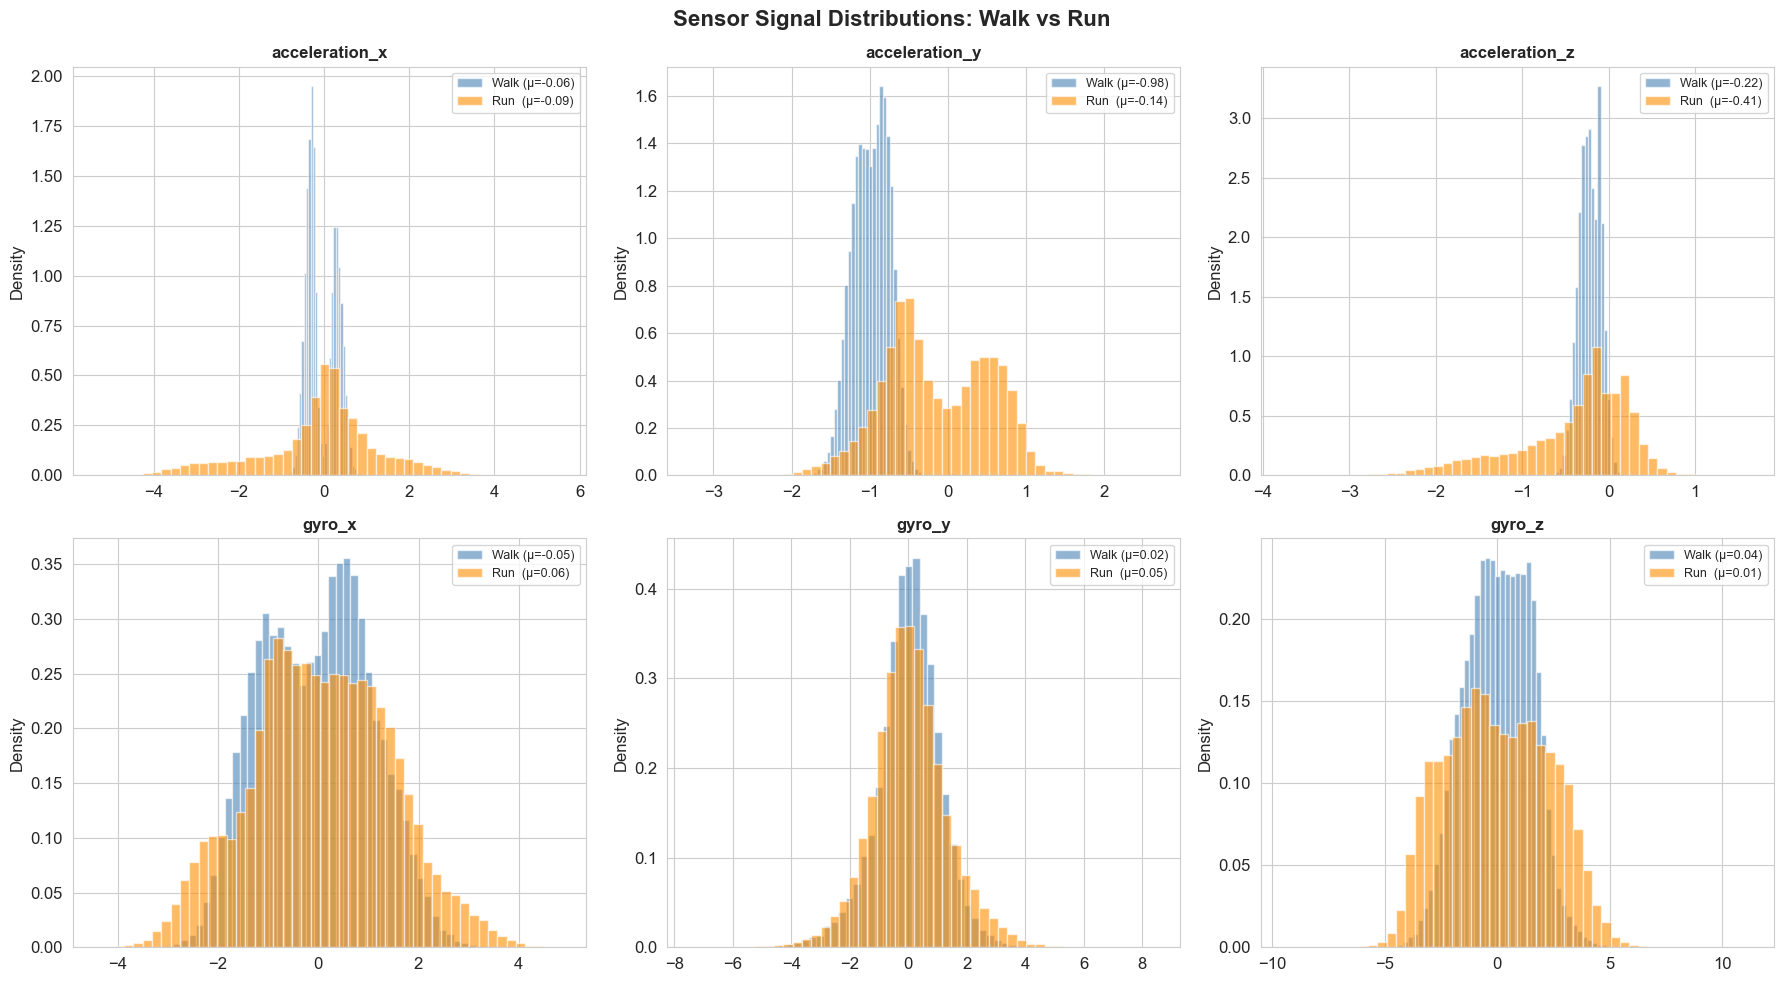

In [9]:
sensor_cols = ['acceleration_x', 'acceleration_y', 'acceleration_z',
               'gyro_x', 'gyro_y', 'gyro_z']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sensor Signal Distributions: Walk vs Run', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    walk_data = df[df['activity'] == 0][col]
    run_data  = df[df['activity'] == 1][col]

    axes[i].hist(walk_data, bins=50, alpha=0.6, color='steelblue',
                 label=f'Walk (μ={walk_data.mean():.2f})', density=True)
    axes[i].hist(run_data, bins=50, alpha=0.6, color='darkorange',
                 label=f'Run  (μ={run_data.mean():.2f})', density=True)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.savefig('sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

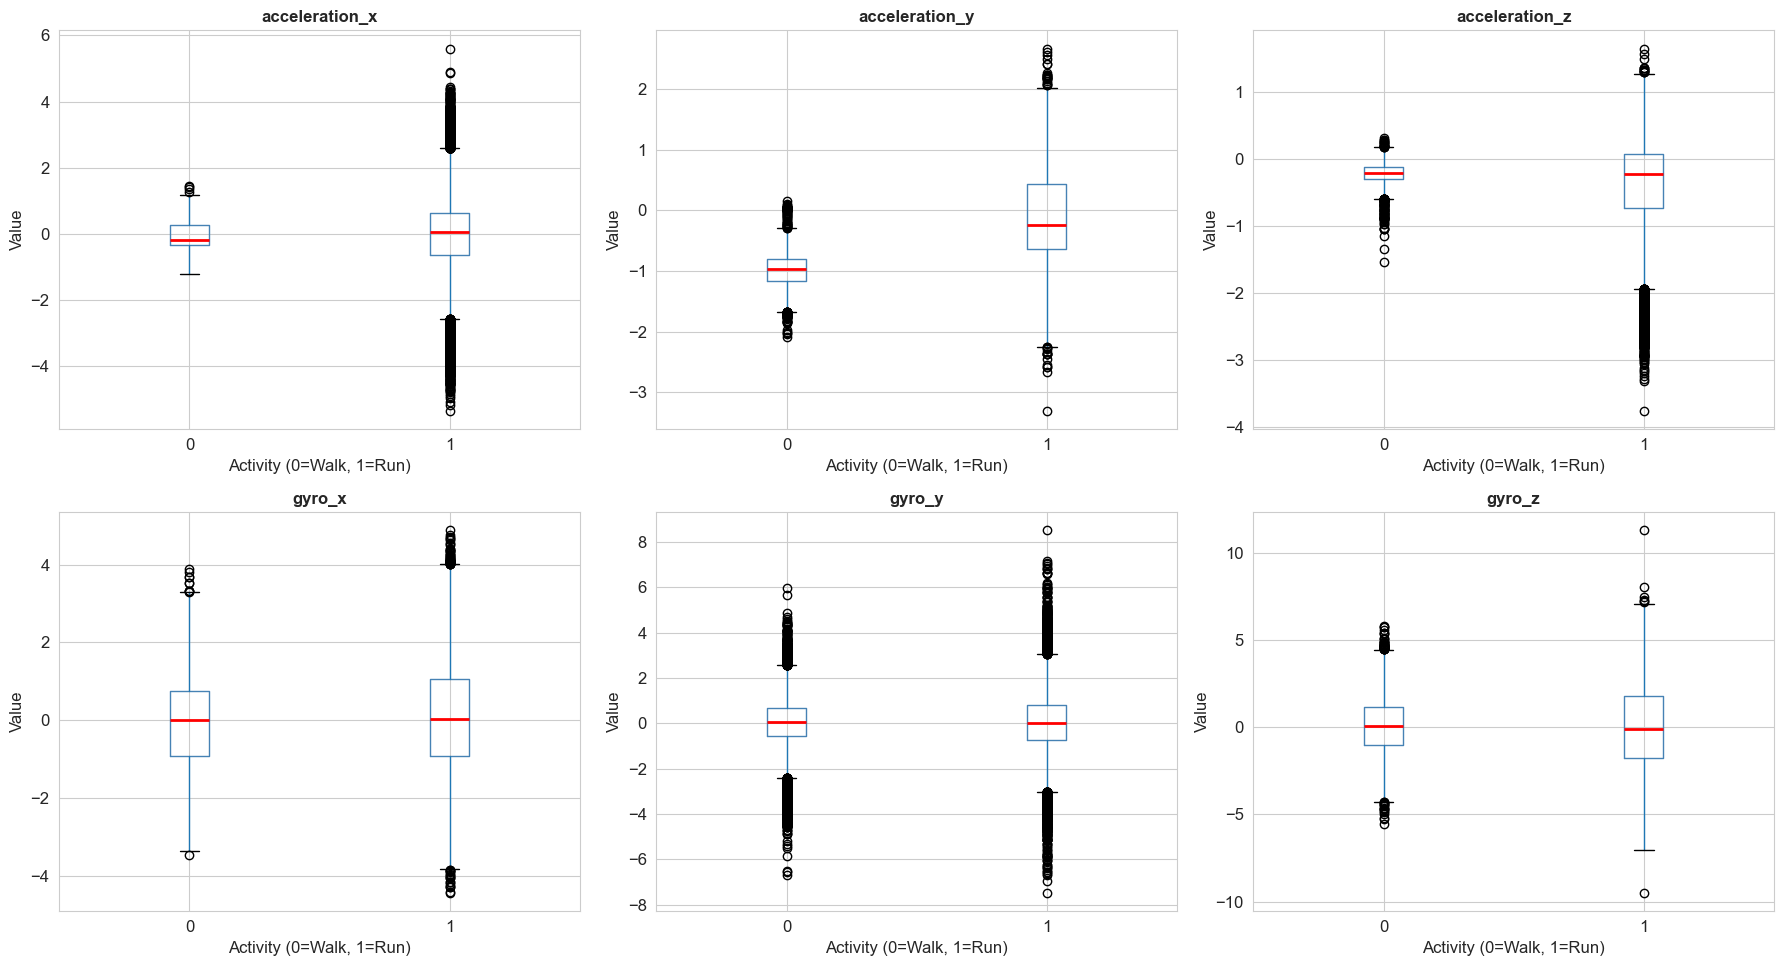

In [10]:
# Box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sensor Box Plots: Walk vs Run', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    df.boxplot(column=col, by='activity', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Activity (0=Walk, 1=Run)')
    axes[i].set_ylabel('Value')

plt.suptitle('')
plt.tight_layout()
plt.savefig('sensor_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

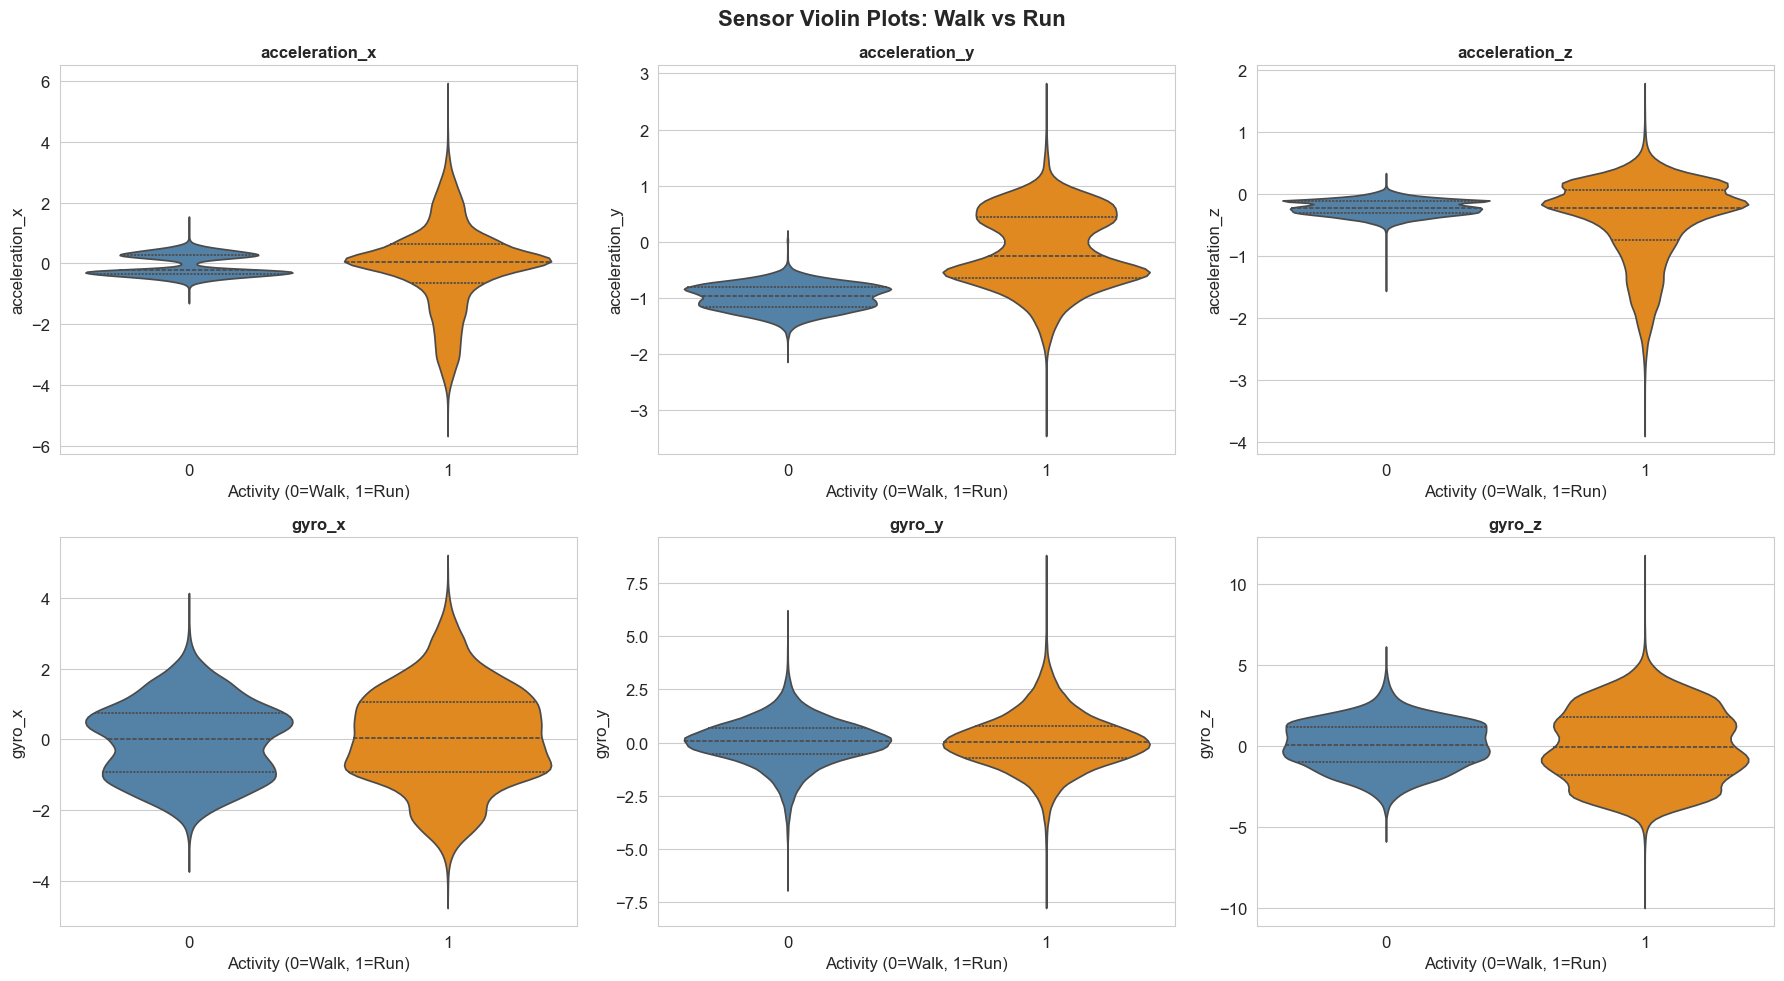

In [11]:
# Violin plots — richer view of distribution shape
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sensor Violin Plots: Walk vs Run', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.violinplot(data=df, x='activity', y=col, ax=axes[i],
                   palette={'0' : 'steelblue', '1' : 'darkorange'},
                   inner='quartile')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Activity (0=Walk, 1=Run)')

plt.tight_layout()
plt.savefig('sensor_violin.png', dpi=150, bbox_inches='tight')
plt.show()

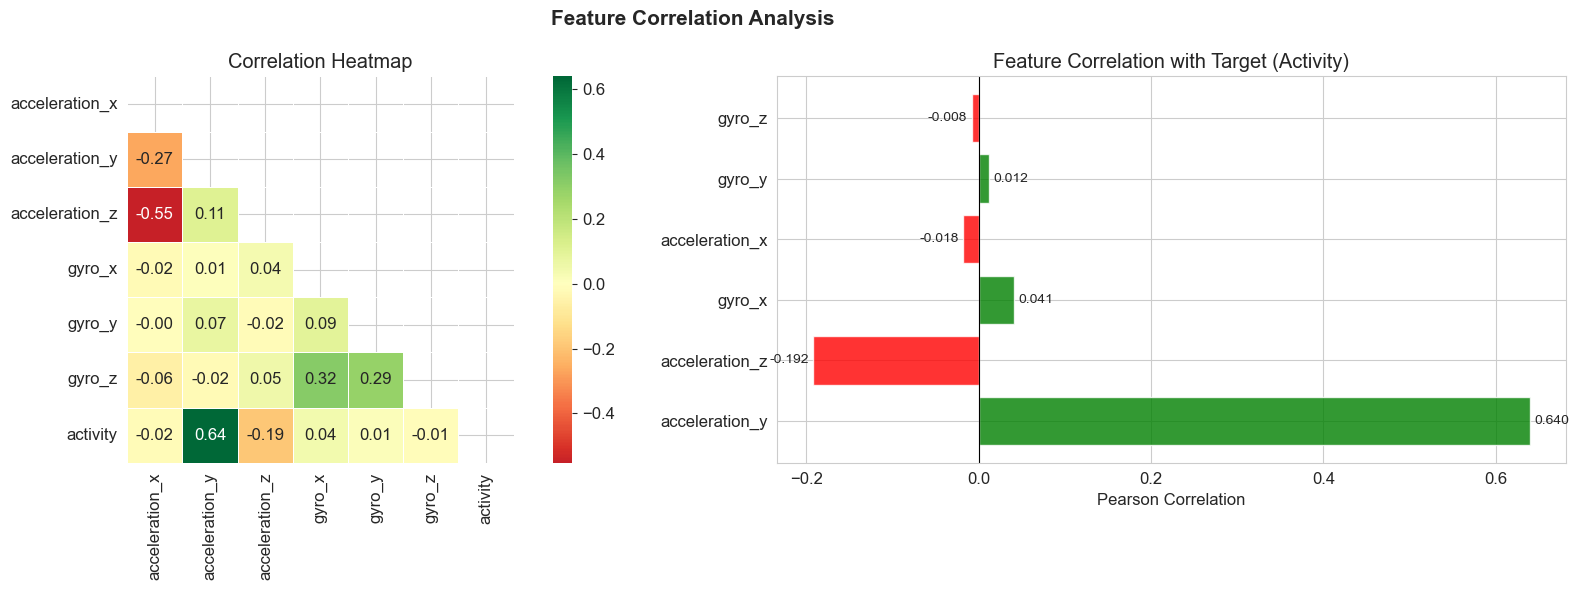

In [12]:
corr_cols = sensor_cols + ['activity']
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Correlation Analysis', fontsize=15, fontweight='bold')

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            square=True, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# Correlation with target
target_corr = corr_matrix['activity'].drop('activity').sort_values(key=abs, ascending=False)
colors = ['green' if v > 0 else 'red' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Target (Activity)')
axes[1].set_xlabel('Pearson Correlation')
for i, (feat, val) in enumerate(target_corr.items()):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

=== Unique Users ===
username
viktor    88588
Name: count, dtype: int64


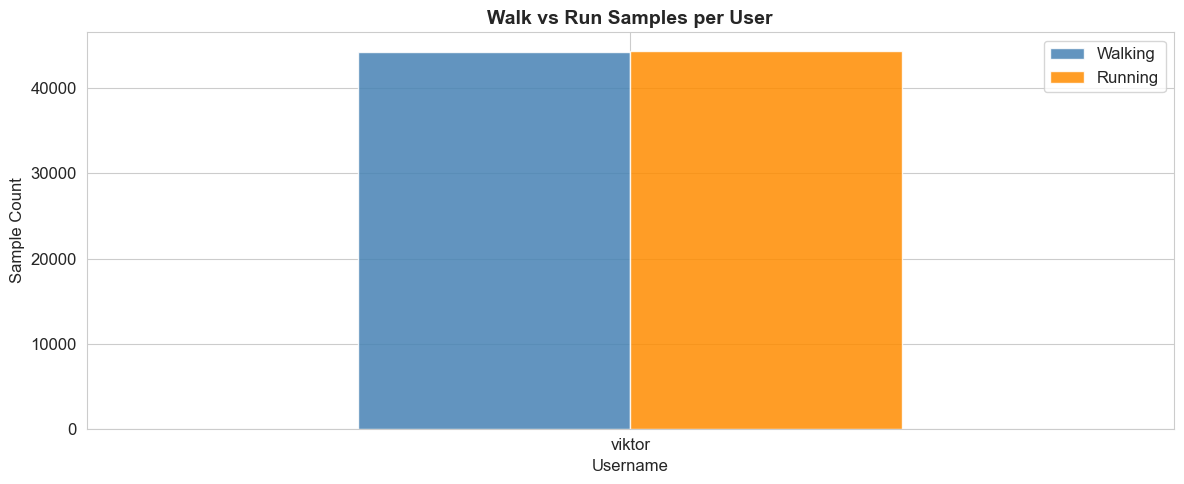

In [13]:
print('=== Unique Users ===')
print(df['username'].value_counts())

user_activity = df.groupby(['username', 'activity']).size().unstack(fill_value=0)
user_activity.columns = ['Walking', 'Running']

user_activity.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'darkorange'],
                   alpha=0.85, edgecolor='white')
plt.title('Walk vs Run Samples per User', fontsize=14, fontweight='bold')
plt.xlabel('Username')
plt.ylabel('Sample Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Per-user sensor stats
user_sensor = df.groupby('username')[sensor_cols].mean().round(3)
print('\nMean Sensor Readings per User:')
user_sensor.style.background_gradient(cmap='coolwarm', axis=0)


Mean Sensor Readings per User:


,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
username,,,,,,
viktor,-0.075000,-0.563000,-0.314000,0.004000,0.037000,0.022000


Wrist values: [0 1]
0 = dominant wrist | 1 = non-dominant wrist



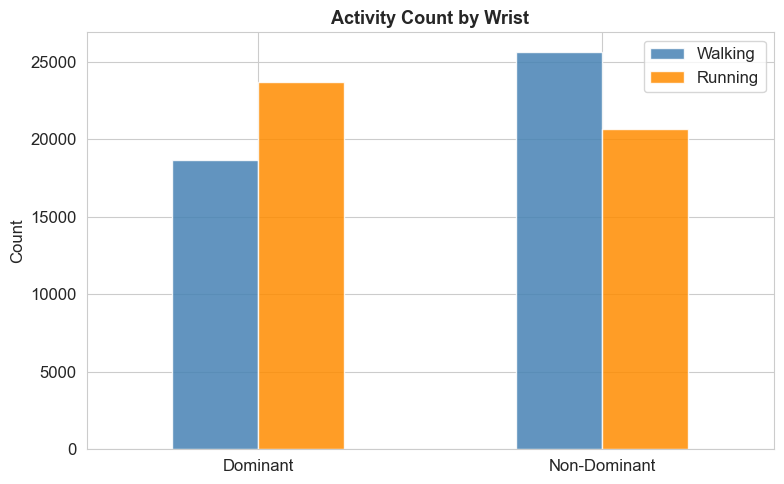

In [15]:
print('Wrist values:', df['wrist'].unique())
print('0 = dominant wrist | 1 = non-dominant wrist\n')

wrist_activity = df.groupby(['wrist', 'activity']).size().unstack(fill_value=0)
wrist_activity.columns = ['Walking', 'Running']
wrist_activity.index = ['Dominant', 'Non-Dominant']

wrist_activity.plot(kind='bar', color=['steelblue', 'darkorange'],
                    alpha=0.85, figsize=(8, 5))
plt.title('Activity Count by Wrist', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('wrist_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

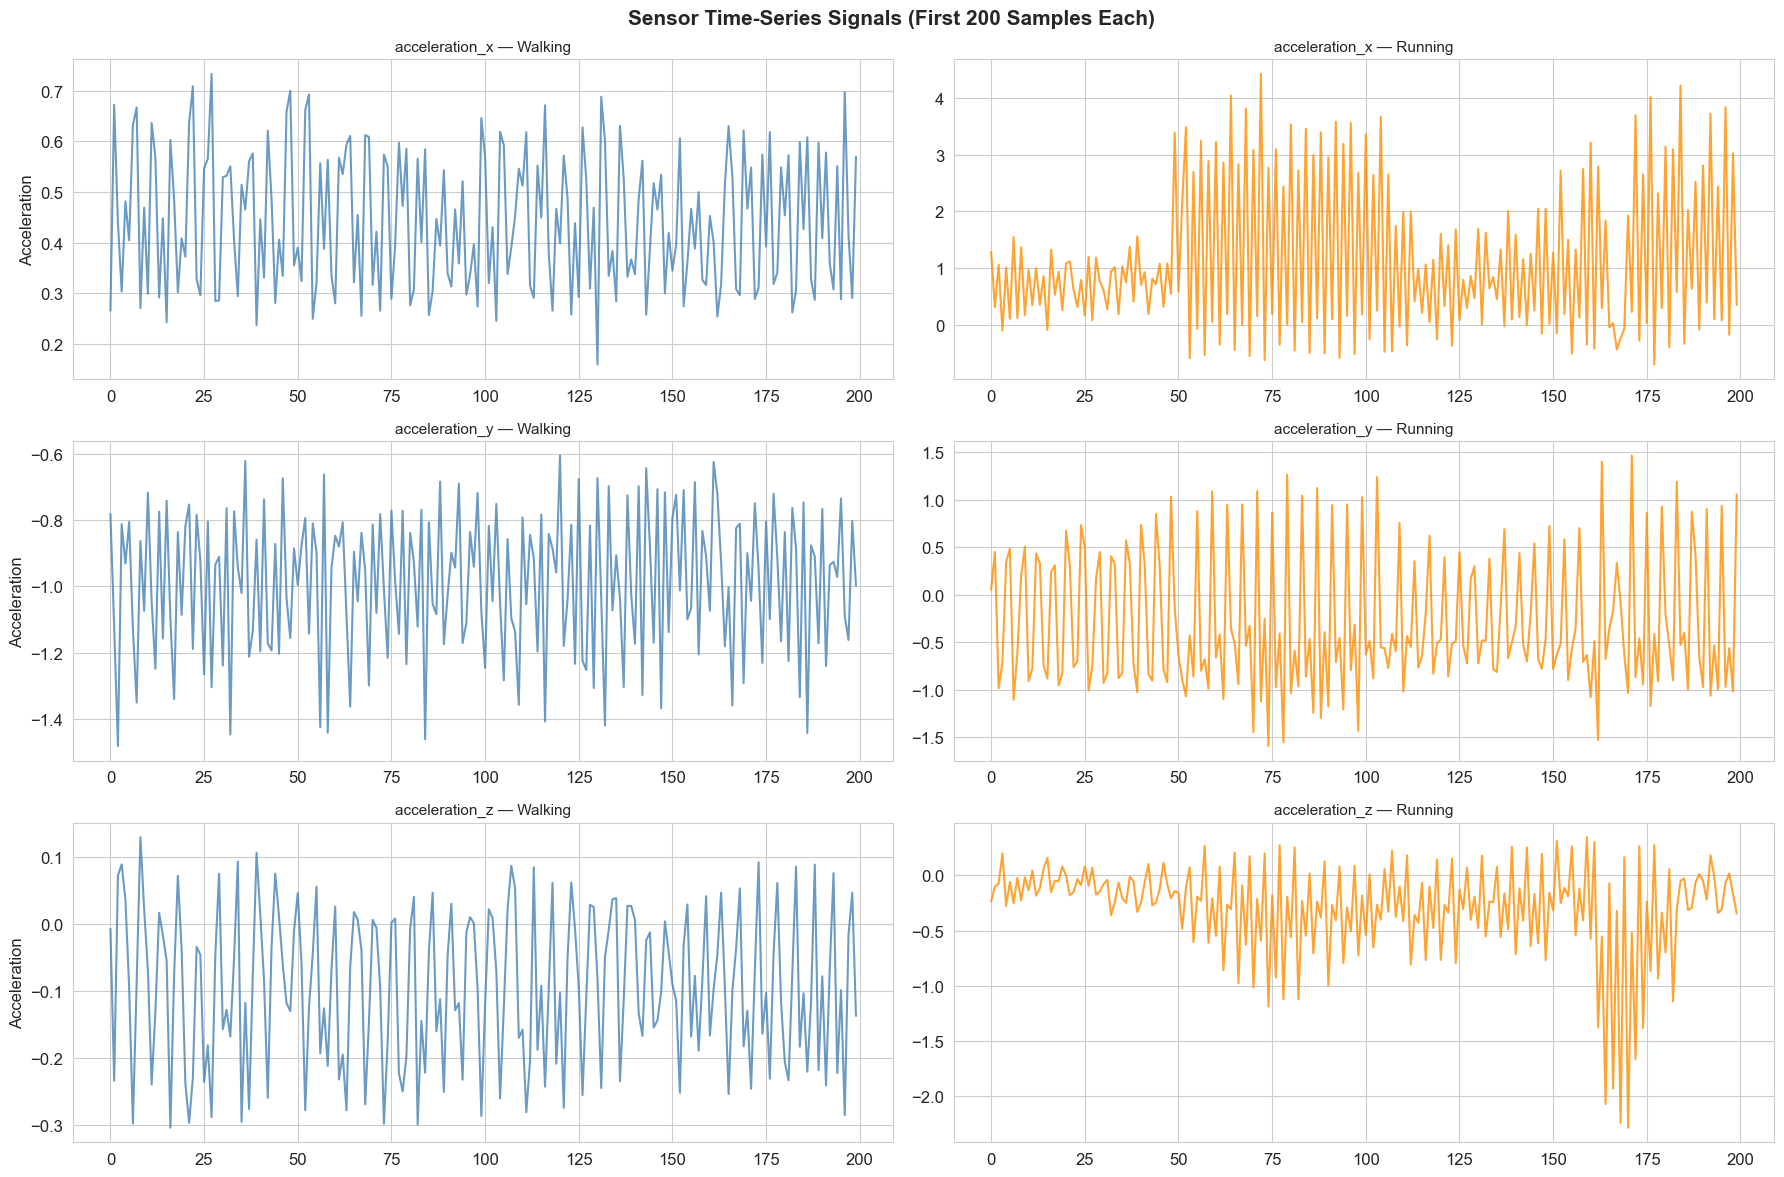

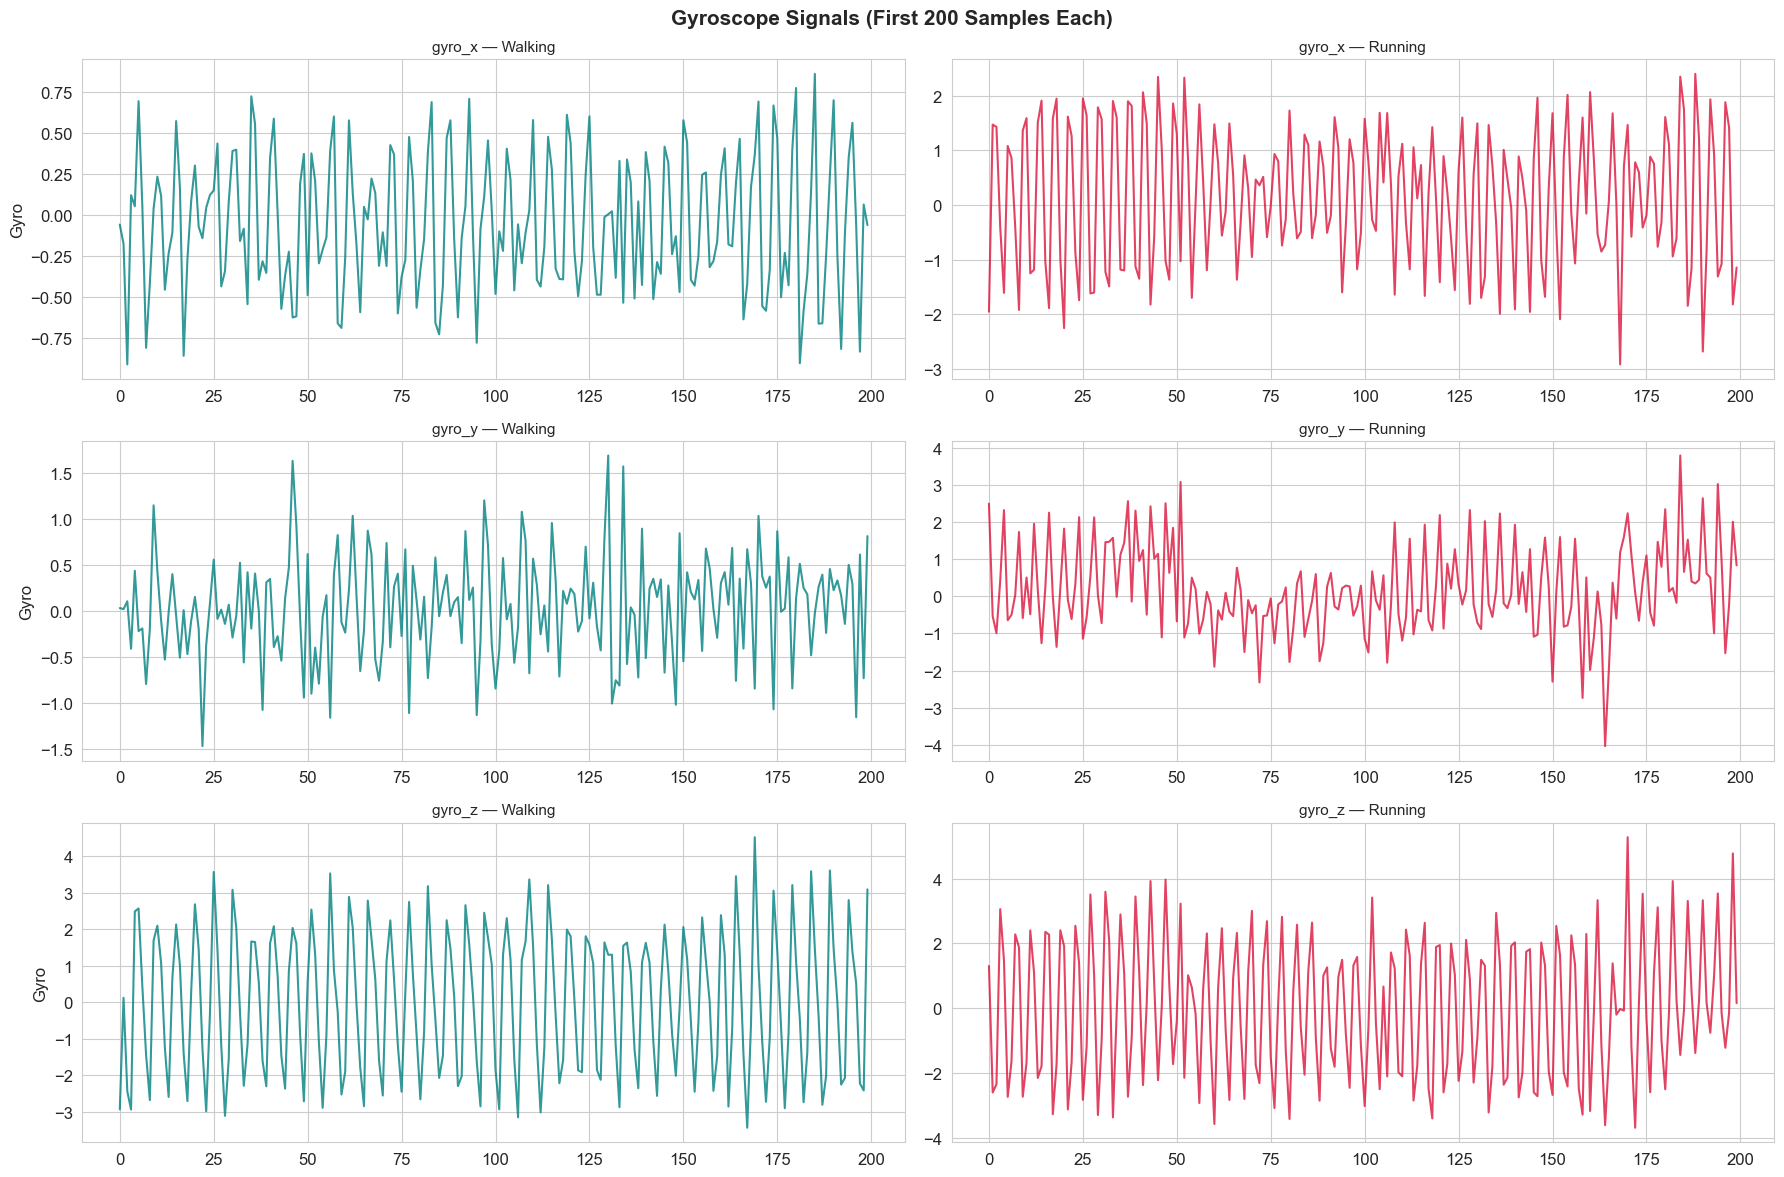

In [16]:
# Show first 200 samples of acceleration_x for walk vs run
walk_sample = df[df['activity'] == 0].head(200)
run_sample  = df[df['activity'] == 1].head(200)

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Sensor Time-Series Signals (First 200 Samples Each)', fontsize=15, fontweight='bold')

accel_cols = ['acceleration_x', 'acceleration_y', 'acceleration_z']
gyro_cols  = ['gyro_x', 'gyro_y', 'gyro_z']

for i, col in enumerate(accel_cols):
    axes[i, 0].plot(walk_sample[col].values, color='steelblue', alpha=0.8, label='Walk')
    axes[i, 0].set_title(f'{col} — Walking', fontsize=11)
    axes[i, 0].set_ylabel('Acceleration')
    axes[i, 1].plot(run_sample[col].values, color='darkorange', alpha=0.8, label='Run')
    axes[i, 1].set_title(f'{col} — Running', fontsize=11)

plt.tight_layout()
plt.savefig('timeseries_accel.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Gyroscope Signals (First 200 Samples Each)', fontsize=15, fontweight='bold')

for i, col in enumerate(gyro_cols):
    axes[i, 0].plot(walk_sample[col].values, color='teal', alpha=0.8, label='Walk')
    axes[i, 0].set_title(f'{col} — Walking', fontsize=11)
    axes[i, 0].set_ylabel('Gyro')
    axes[i, 1].plot(run_sample[col].values, color='crimson', alpha=0.8, label='Run')
    axes[i, 1].set_title(f'{col} — Running', fontsize=11)

plt.tight_layout()
plt.savefig('timeseries_gyro.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print('=== Mann-Whitney U Test: Walk vs Run for each sensor ===')
print(f'\n{"Feature":<20} {"Walk Mean":>12} {"Run Mean":>12} {"p-value":>12} {"Significant":>12}')
print('-' * 70)

walk = df[df['activity'] == 0]
run  = df[df['activity'] == 1]

for col in sensor_cols:
    stat, p = stats.mannwhitneyu(walk[col], run[col], alternative='two-sided')
    sig = ' YES' if p < 0.05 else ' NO'
    print(f'{col:<20} {walk[col].mean():>12.4f} {run[col].mean():>12.4f} {p:>12.4e} {sig:>12}')

=== Mann-Whitney U Test: Walk vs Run for each sensor ===

Feature                 Walk Mean     Run Mean      p-value  Significant
----------------------------------------------------------------------
acceleration_x            -0.0569      -0.0927  2.6102e-108          YES
acceleration_y            -0.9844      -0.1422   0.0000e+00          YES
acceleration_z            -0.2201      -0.4075   2.9805e-17          YES
gyro_x                    -0.0471       0.0553   4.3954e-33          YES
gyro_y                     0.0227       0.0516   6.2187e-04          YES
gyro_z                     0.0379       0.0068   1.6947e-05          YES


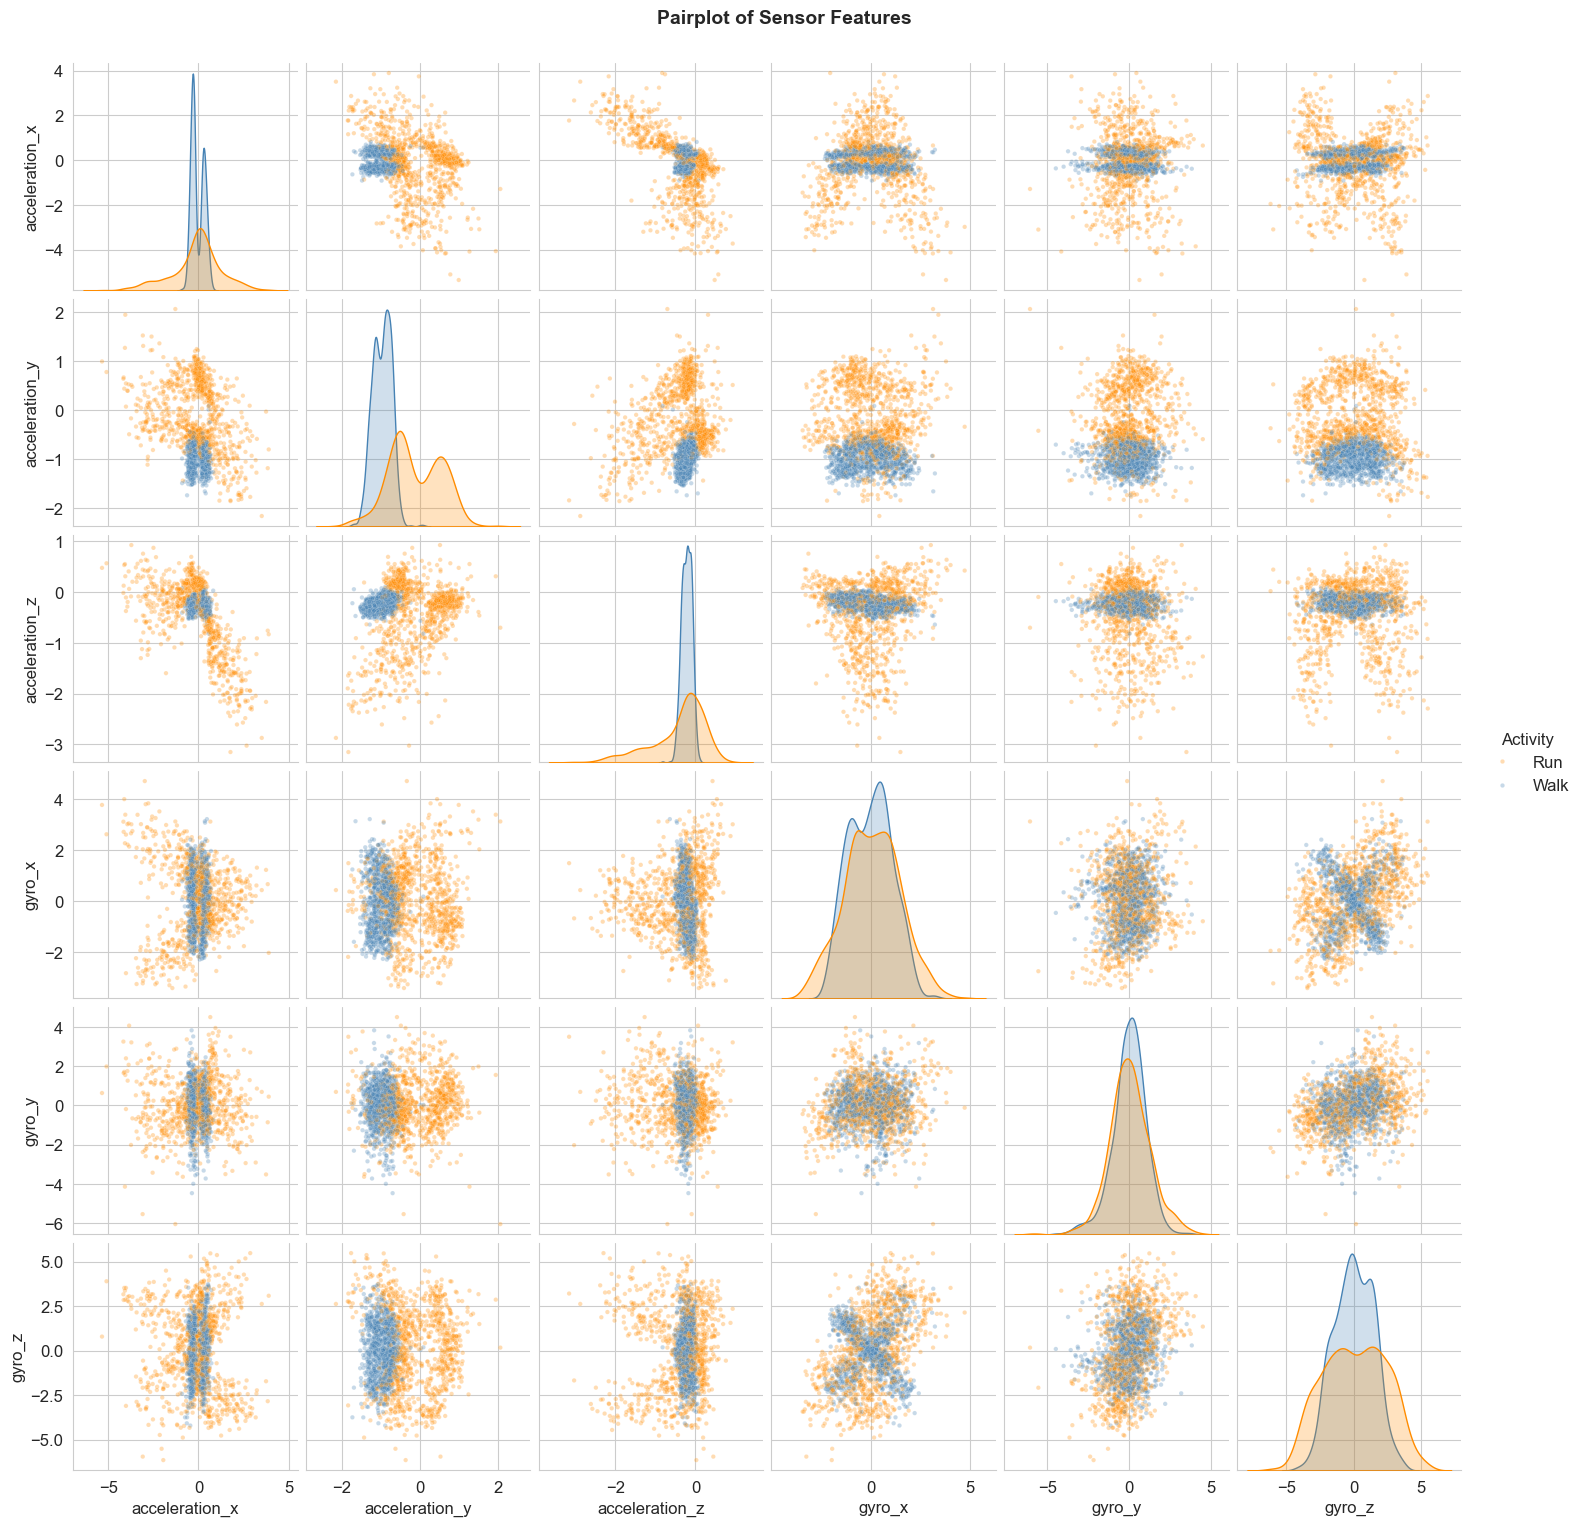

In [18]:
plot_df = df[sensor_cols + ['activity']].sample(n=min(2000, len(df)), random_state=42)
plot_df['Activity'] = plot_df['activity'].map({0: 'Walk', 1: 'Run'})

g = sns.pairplot(plot_df.drop('activity', axis=1),
                 hue='Activity',
                 palette={'Walk': 'steelblue', 'Run': 'darkorange'},
                 plot_kws={'alpha': 0.3, 's': 10},
                 diag_kind='kde')
g.fig.suptitle('Pairplot of Sensor Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
#Feature Engineering 

df_model = df.copy()

# Magnitude features (Euclidean norm of axes)
df_model['accel_magnitude'] = np.sqrt(
    df_model['acceleration_x']**2 +
    df_model['acceleration_y']**2 +
    df_model['acceleration_z']**2
)

df_model['gyro_magnitude'] = np.sqrt(
    df_model['gyro_x']**2 +
    df_model['gyro_y']**2 +
    df_model['gyro_z']**2
)

# Cross-sensor ratios
df_model['accel_xy_ratio'] = df_model['acceleration_x'] / (df_model['acceleration_y'].abs() + 1e-6)
df_model['accel_xz_ratio'] = df_model['acceleration_x'] / (df_model['acceleration_z'].abs() + 1e-6)

# Squared values (capture intensity)
for col in sensor_cols:
    df_model[f'{col}_sq'] = df_model[col] ** 2

# Absolute values
for col in sensor_cols:
    df_model[f'{col}_abs'] = df_model[col].abs()

print(f'Original features  : {len(sensor_cols) + 2}')
print(f'After engineering  : {df_model.shape[1]}')

Original features  : 8
After engineering  : 27


In [20]:
#Encode categorical cols & select features

# Encode wrist (already 0/1 likely, but ensure int)
df_model['wrist'] = df_model['wrist'].astype(int)

# Drop non-predictive columns
drop_cols = ['date', 'time', 'username']
df_model.drop([c for c in drop_cols if c in df_model.columns], axis=1, inplace=True)

# Feature matrix and target
X = df_model.drop('activity', axis=1)
y = df_model['activity']

print(f'Feature matrix shape : {X.shape}')
print(f'Target shape         : {y.shape}')
print(f'Features used        : {X.columns.tolist()}')

Feature matrix shape : (88588, 23)
Target shape         : (88588,)
Features used        : ['wrist', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z', 'accel_magnitude', 'gyro_magnitude', 'accel_xy_ratio', 'accel_xz_ratio', 'acceleration_x_sq', 'acceleration_y_sq', 'acceleration_z_sq', 'gyro_x_sq', 'gyro_y_sq', 'gyro_z_sq', 'acceleration_x_abs', 'acceleration_y_abs', 'acceleration_z_abs', 'gyro_x_abs', 'gyro_y_abs', 'gyro_z_abs']


In [21]:
#Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]:,} samples')
print(f'Test size  : {X_test.shape[0]:,} samples')
print(f'\nTrain class balance:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nTest class balance:')
print(y_test.value_counts(normalize=True).round(3))

Train size : 70,870 samples
Test size  : 17,718 samples

Train class balance:
activity
1    0.501
0    0.499
Name: proportion, dtype: float64

Test class balance:
activity
1    0.501
0    0.499
Name: proportion, dtype: float64


In [22]:
#Scale Features 

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(' Features scaled with StandardScaler.')

 Features scaled with StandardScaler.


In [23]:
#Evaluation utility

all_results = []

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te,
                         model_name='Model', scaled=True):
    
    #Fit, evaluate, and return metrics for a classifier.
    #If scaled=True uses pre-scaled data, else raw data.
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    cv = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f'\n{"─"*55}')
    print(f'  {model_name}')
    print(f'{"─"*55}')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  F1 Score   : {f1:.4f}')
    if auc: print(f'  ROC-AUC    : {auc:.4f}')
    print(f'  CV Acc     : {cv.mean():.4f} ± {cv.std():.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_te, y_pred,
                                target_names=['Walk', 'Run']))

    result = {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1_Score': round(f1, 4),
        'ROC_AUC': round(auc, 4) if auc else None,
        'CV_Accuracy': round(cv.mean(), 4)
    }
    all_results.append(result)
    return result, model, y_pred, y_prob

print(' Evaluation function ready.')

 Evaluation function ready.


In [24]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr_res, lr_fit, lr_pred, lr_prob = evaluate_classifier(
    lr, X_train_sc, y_train, X_test_sc, y_test, 'Logistic Regression'
)


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
  Accuracy   : 0.9756
  Precision  : 0.9871
  Recall     : 0.9639
  F1 Score   : 0.9754
  ROC-AUC    : 0.9964
  CV Acc     : 0.9762 ± 0.0011

  Classification Report:
              precision    recall  f1-score   support

        Walk       0.96      0.99      0.98      8845
         Run       0.99      0.96      0.98      8873

    accuracy                           0.98     17718
   macro avg       0.98      0.98      0.98     17718
weighted avg       0.98      0.98      0.98     17718



In [25]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_res, rf_fit, rf_pred, rf_prob = evaluate_classifier(
    rf, X_train, y_train, X_test, y_test, 'Random Forest'
)


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  Accuracy   : 0.9867
  Precision  : 0.9895
  Recall     : 0.9839
  F1 Score   : 0.9867
  ROC-AUC    : 0.9989
  CV Acc     : 0.9867 ± 0.0007

  Classification Report:
              precision    recall  f1-score   support

        Walk       0.98      0.99      0.99      8845
         Run       0.99      0.98      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



In [26]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,          # L2 regularization
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp_res, mlp_fit, mlp_pred, mlp_prob = evaluate_classifier(
    mlp, X_train_sc, y_train, X_test_sc, y_test, 'Neural Network (MLP)'
)


───────────────────────────────────────────────────────
  Neural Network (MLP)
───────────────────────────────────────────────────────
  Accuracy   : 0.9933
  Precision  : 0.9964
  Recall     : 0.9902
  F1 Score   : 0.9933
  ROC-AUC    : 0.9996
  CV Acc     : 0.9933 ± 0.0005

  Classification Report:
              precision    recall  f1-score   support

        Walk       0.99      1.00      0.99      8845
         Run       1.00      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



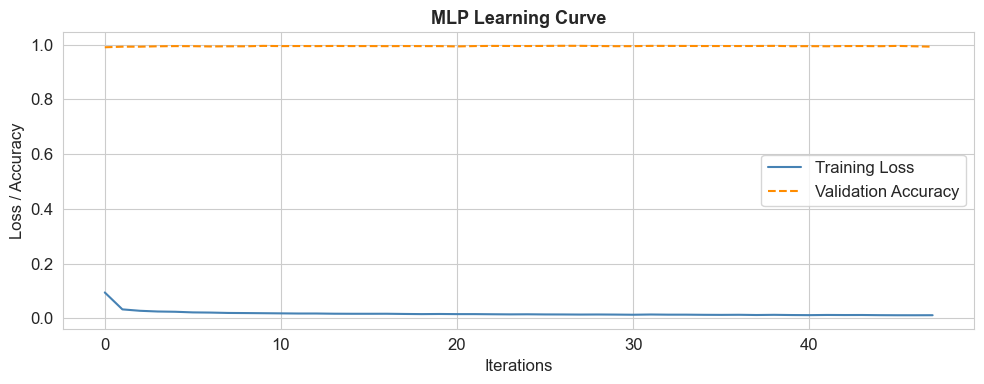

In [27]:
# MLP Learning Curve
plt.figure(figsize=(10, 4))
plt.plot(mlp_fit.loss_curve_, label='Training Loss', color='steelblue')
if mlp_fit.validation_scores_ is not None:
    plt.plot(mlp_fit.validation_scores_, label='Validation Accuracy',
             color='darkorange', linestyle='--')
plt.title('MLP Learning Curve', fontsize=13, fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('Loss / Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_res, xgb_fit, xgb_pred, xgb_prob = evaluate_classifier(
    xgb_model, X_train, y_train, X_test, y_test, 'XGBoost'
)


───────────────────────────────────────────────────────
  XGBoost
───────────────────────────────────────────────────────
  Accuracy   : 0.9923
  Precision  : 0.9936
  Recall     : 0.9911
  F1 Score   : 0.9923
  ROC-AUC    : 0.9995
  CV Acc     : 0.9925 ± 0.0006

  Classification Report:
              precision    recall  f1-score   support

        Walk       0.99      0.99      0.99      8845
         Run       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



In [30]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
gb_res, gb_fit, gb_pred, gb_prob = evaluate_classifier(
    gb, X_train, y_train, X_test, y_test, 'Gradient Boosting'
)


───────────────────────────────────────────────────────
  Gradient Boosting
───────────────────────────────────────────────────────
  Accuracy   : 0.9909
  Precision  : 0.9925
  Recall     : 0.9892
  F1 Score   : 0.9909
  ROC-AUC    : 0.9994
  CV Acc     : 0.9912 ± 0.0007

  Classification Report:
              precision    recall  f1-score   support

        Walk       0.99      0.99      0.99      8845
         Run       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



In [31]:
results_df = pd.DataFrame(all_results).sort_values('F1_Score', ascending=False)

print('\n' + '='*75)
print('         MODEL COMPARISON REPORT — Walk/Run Classification')
print('='*75)
print(results_df.to_string(index=False))
print('\n(Higher values = better for all metrics)')

best = results_df.iloc[0]
print(f'\n Best Model: {best["Model"]}')
print(f'   F1: {best["F1_Score"]} | Accuracy: {best["Accuracy"]} | ROC-AUC: {best["ROC_AUC"]}')


         MODEL COMPARISON REPORT — Walk/Run Classification
               Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC  CV_Accuracy
Neural Network (MLP)    0.9933     0.9964  0.9902    0.9933   0.9996       0.9933
             XGBoost    0.9923     0.9936  0.9911    0.9923   0.9995       0.9925
   Gradient Boosting    0.9909     0.9925  0.9892    0.9909   0.9994       0.9912
   Gradient Boosting    0.9909     0.9925  0.9892    0.9909   0.9994       0.9912
       Random Forest    0.9867     0.9895  0.9839    0.9867   0.9989       0.9867
 Logistic Regression    0.9756     0.9871  0.9639    0.9754   0.9964       0.9762

(Higher values = better for all metrics)

 Best Model: Neural Network (MLP)
   F1: 0.9933 | Accuracy: 0.9933 | ROC-AUC: 0.9996


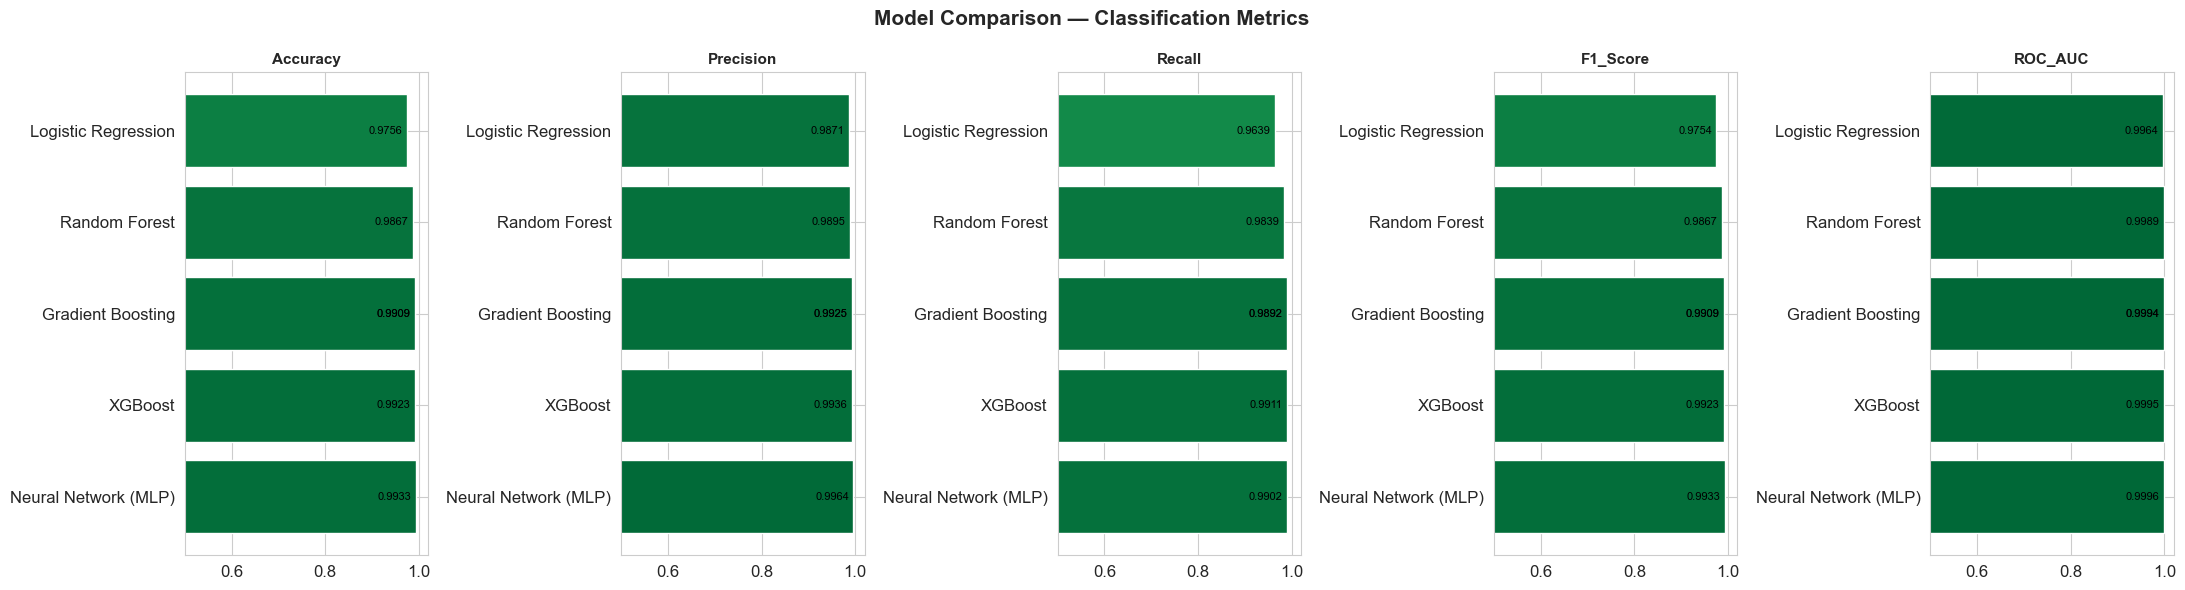

In [32]:
# Visual Model Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
results_plot = results_df.set_index('Model')[metrics]

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Model Comparison — Classification Metrics', fontsize=15, fontweight='bold')
cmap = plt.cm.get_cmap('RdYlGn')

for ax, metric in zip(axes, metrics):
    vals = results_plot[metric].fillna(0)
    colors = [cmap((v - 0.5) / 0.5) for v in vals]
    bars = ax.barh(results_plot.index, vals, color=colors)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xlim(0.5, 1.02)
    for bar, val in zip(bars, vals):
        ax.text(val - 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='right', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

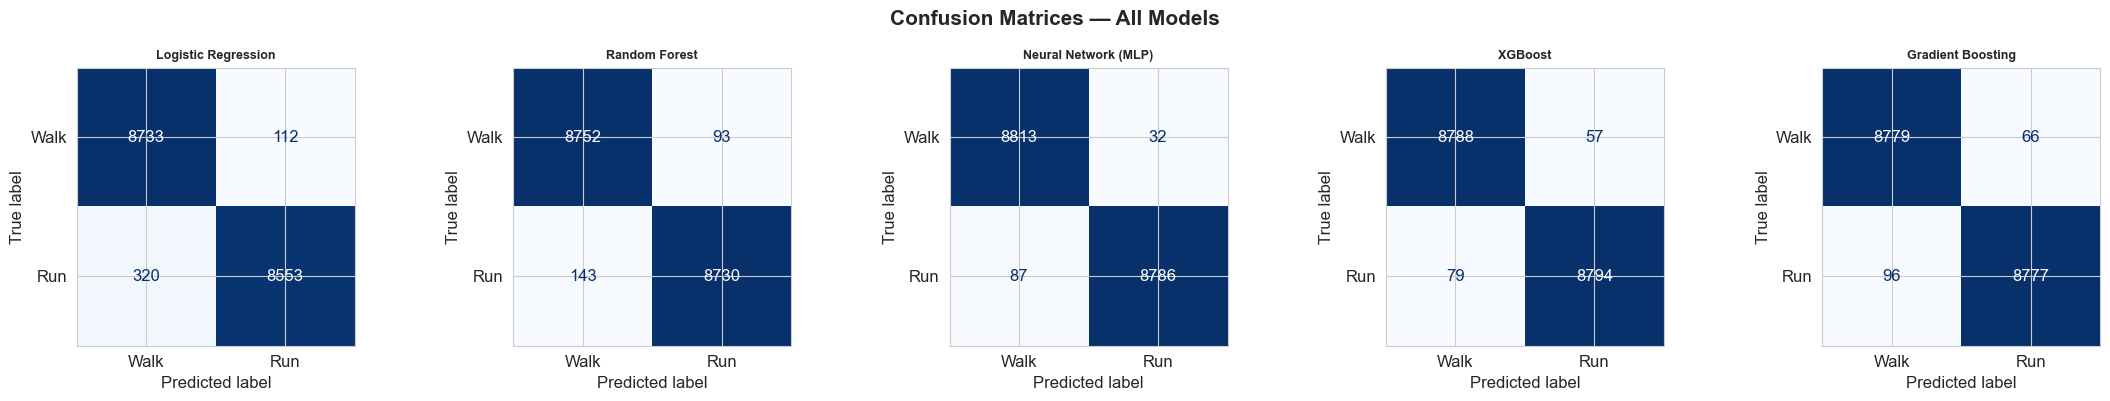

In [33]:
models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Neural Network (MLP)', mlp_pred),
    ('XGBoost',             xgb_pred),
    ('Gradient Boosting',   gb_pred),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Walk', 'Run'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

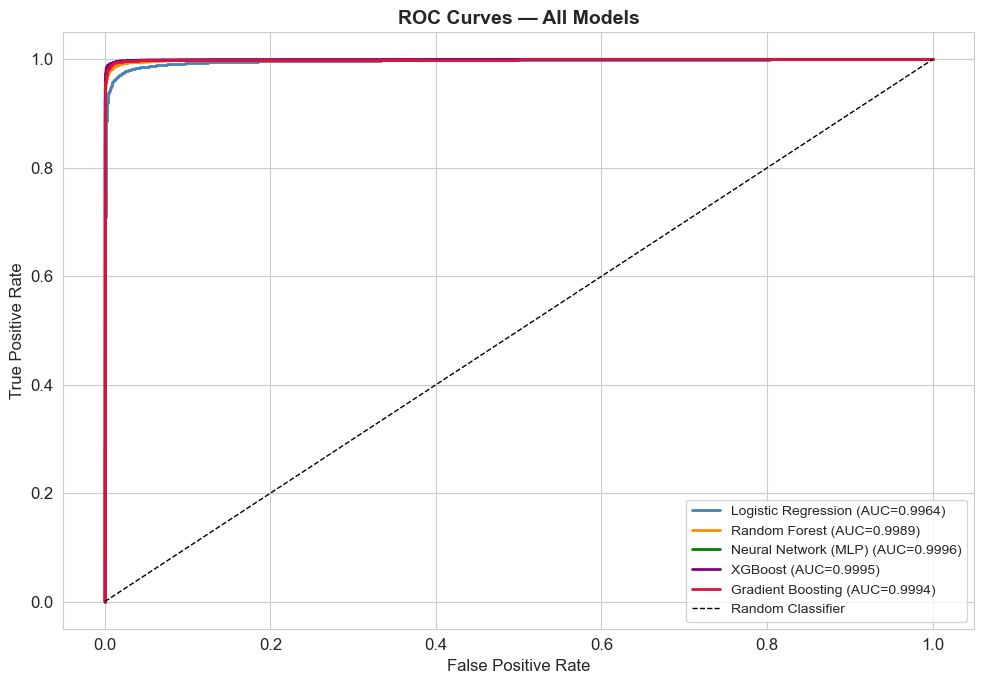

In [34]:
roc_info = [
    ('Logistic Regression',  lr_prob,  lr_res['ROC_AUC']),
    ('Random Forest',         rf_prob,  rf_res['ROC_AUC']),
    ('Neural Network (MLP)', mlp_prob, mlp_res['ROC_AUC']),
    ('XGBoost',              xgb_prob, xgb_res['ROC_AUC']),
    ('Gradient Boosting',    gb_prob,  gb_res['ROC_AUC']),
]

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'purple', 'crimson']

for (name, prob, auc_val), color in zip(roc_info, colors):
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})',
                 color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

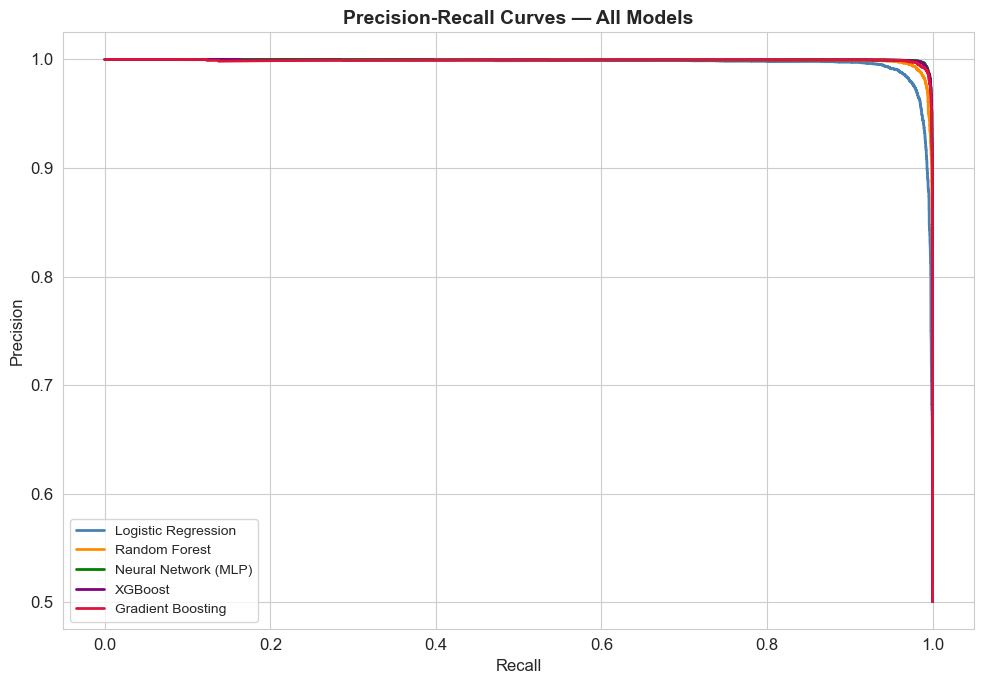

In [35]:
plt.figure(figsize=(10, 7))

for (name, prob, _), color in zip(roc_info, colors):
    if prob is not None:
        prec_arr, rec_arr, _ = precision_recall_curve(y_test, prob)
        plt.plot(rec_arr, prec_arr, label=name, color=color, linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

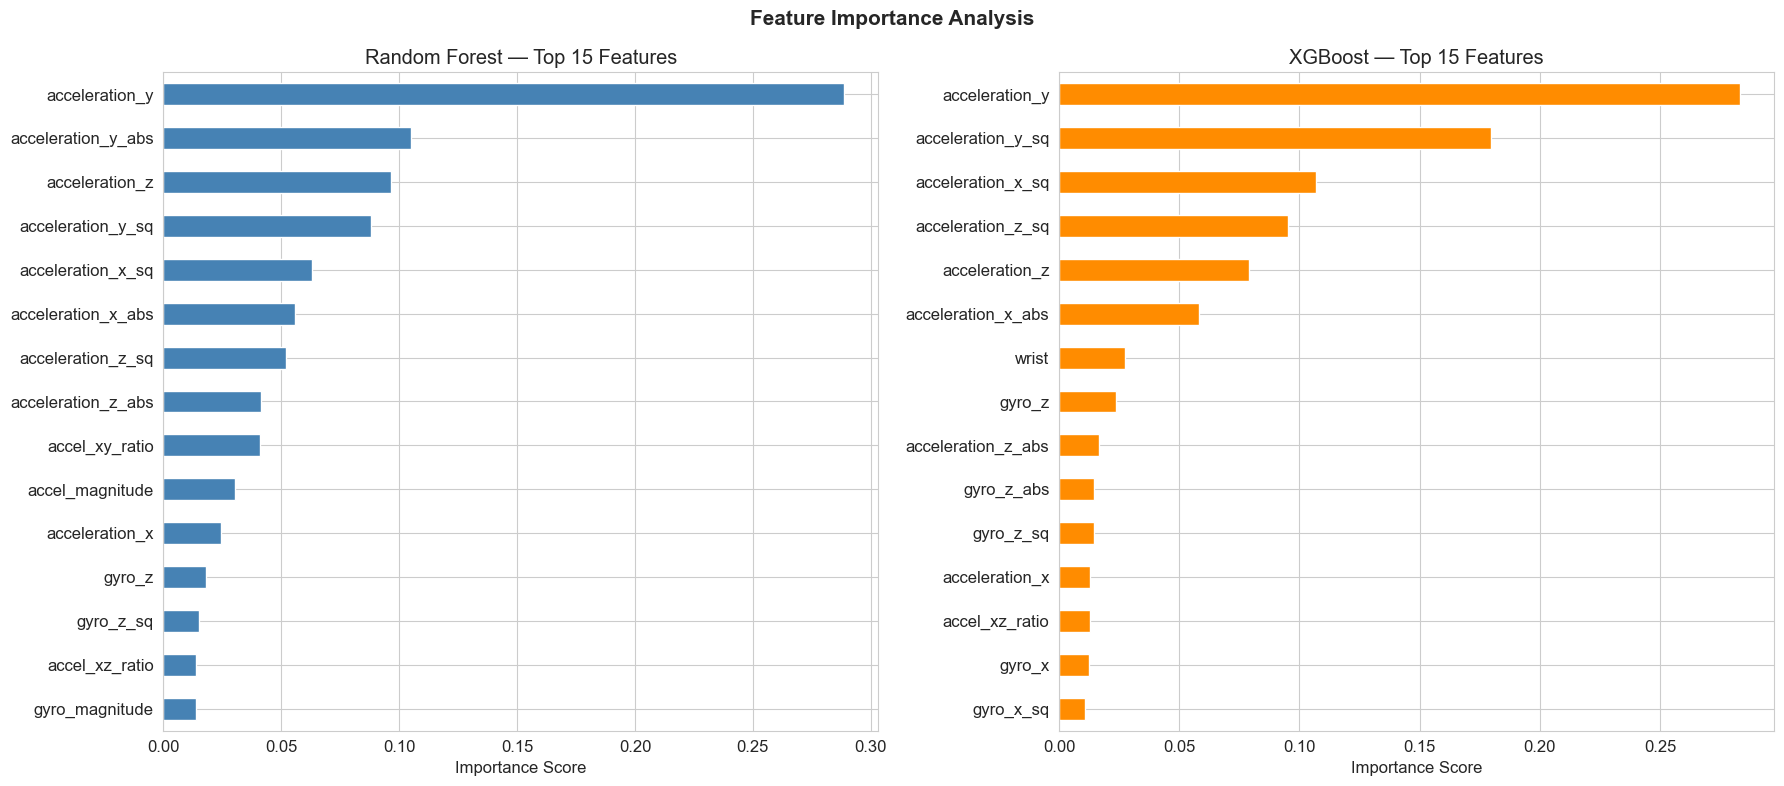

Top 10 Features (Random Forest):
acceleration_y        0.288723
acceleration_y_abs    0.104849
acceleration_z        0.096333
acceleration_y_sq     0.088218
acceleration_x_sq     0.062876
acceleration_x_abs    0.055980
acceleration_z_sq     0.051842
acceleration_z_abs    0.041499
accel_xy_ratio        0.040805
accel_magnitude       0.030203


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold')

# Random Forest
rf_imp = pd.Series(rf_fit.feature_importances_, index=X_train.columns)\
           .sort_values(ascending=False).head(15)
rf_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_imp = pd.Series(xgb_fit.feature_importances_, index=X_train.columns)\
            .sort_values(ascending=False).head(15)
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost — Top 15 Features')
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Features (Random Forest):')
print(rf_imp.head(10).to_string())

In [37]:
# Save best model
import joblib

joblib.dump(xgb_fit, 'best_model_xgb.pkl')
joblib.dump(scaler,  'scaler.pkl')
print(' Best model (XGBoost) saved as: best_model_xgb.pkl')
print(' Scaler saved as: scaler.pkl')

 Best model (XGBoost) saved as: best_model_xgb.pkl
 Scaler saved as: scaler.pkl


In [40]:
def predict_activity(accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z, wrist=0):
    """
    Predict Walk or Run from raw sensor readings.
    Parameters:
    - accel_x/y/z : accelerometer readings
    - gyro_x/y/z  : gyroscope readings
    - wrist        : 0=dominant, 1=non-dominant

    Returns: 'Walking' or 'Running'
    """
    # Build input row
    raw = {
        'wrist': wrist,
        'acceleration_x': accel_x,
        'acceleration_y': accel_y,
        'acceleration_z': accel_z,
        'gyro_x': gyro_x,
        'gyro_y': gyro_y,
        'gyro_z': gyro_z
    }

    # Feature engineering
    raw['accel_magnitude'] = np.sqrt(accel_x**2 + accel_y**2 + accel_z**2)
    raw['gyro_magnitude']  = np.sqrt(gyro_x**2 + gyro_y**2 + gyro_z**2)
    raw['accel_xy_ratio']  = accel_x / (abs(accel_y) + 1e-6)
    raw['accel_xz_ratio']  = accel_x / (abs(accel_z) + 1e-6)

    for col in ['acceleration_x','acceleration_y','acceleration_z','gyro_x','gyro_y','gyro_z']:
        raw[f'{col}_sq']  = raw[col] ** 2
        raw[f'{col}_abs'] = abs(raw[col])

    row = pd.DataFrame([raw])[X_train.columns]  # ensure column order
    pred = xgb_fit.predict(row)[0]
    prob = xgb_fit.predict_proba(row)[0]

    label = 'Running ' if pred == 1 else 'Walking '
    print(f'Prediction : {label}')
    print(f'Confidence : Walk={prob[0]:.2%} | Run={prob[1]:.2%}')
    return label


# Example predictions
print('=== Sample Inference ===')
print('\n Sample 1 (likely Walking):')
predict_activity(0.5, 0.2, 9.8, 0.01, 0.02, -0.01, wrist=0)

print('\n Sample 2 (likely Running):')
predict_activity(3.5, -2.1, 8.5, 1.5, -0.8, 2.1, wrist=0)

=== Sample Inference ===

 Sample 1 (likely Walking):
Prediction : Running 
Confidence : Walk=0.08% | Run=99.92%

 Sample 2 (likely Running):
Prediction : Running 
Confidence : Walk=0.02% | Run=99.98%


'Running '